## *Alaa Asfour, Jason Quantrill, Million Solomon, Murrium Zaheer, Xiaodan Bi*
 500854838, 501036139, 501280237, 500269037, 501049279  
{alaa.asfour, jason.quantrill, million.solomon, mzaheer, xiaodan.bi}@torontomu.ca  
Computer Science Department, Toronto Metropolitan University, Toronto, Canada

# Emotion Detection System (EDS)
###Classification of FER2013 Dataset with MobileNetV2

In [ ]:
!pip install  tensorflow


# Preprocessing

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
import cv2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns




# Load FER2013 dataset from the train CSV file
def load_fer2013_dataset(train_file):
    train_df = pd.read_csv(train_file)

    # Extract pixel data and labels from the training set
    X = np.array([np.fromstring(pixels, dtype=int, sep=' ').reshape(48, 48)
                  for pixels in train_df['pixels']])
    y = train_df['emotion'].values

    # Normalize the pixel values (0 to 255 -> 0 to 1)
    X = X / 255.0
    X = X.reshape(-1, 48, 48, 1)

    # Convert labels to one-hot encoding
    y = to_categorical(y, 7)

    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, y_train, X_val, y_val


# Load the dataset
train_file = '/content/drive/MyDrive/CV_Project/train.csv'
X_train, y_train, X_val, y_val = load_fer2013_dataset(train_file)

# Print shapes to verify
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(y_train[0])  # Print the first label in one-hot encoded form



Training data shape: (22967, 48, 48, 1), Training labels shape: (22967, 7)
Validation data shape: (5742, 48, 48, 1), Validation labels shape: (5742, 7)
[0. 0. 0. 0. 1. 0. 0.]


# Data Augmentation

In [ ]:

# Creating an ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=10,      # Rotate the image by up to 10 degrees
    width_shift_range=0.1,  # Shift the image horizontally by up to 10% of the width
    height_shift_range=0.1, # Shift the image vertically by up to 10% of the height
    zoom_range=0.1,         # Zoom in or out by up to 10%
    horizontal_flip=True     # Flip the image horizontally
)


# Fine Tuning MobileNetV2.0

In [ ]:

# Build and fine-tune MobileNetV2
def build_emotion_model(input_shape):
    # Load MobileNetV2 with ImageNet weights, excluding top layers
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the base model layers (we will fine-tune the later layers)
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Global average pooling for feature reduction
    x = Dense(128, activation='relu')(x)  # Dense layer with 128 units
    x = Dropout(0.5)(x)  # Dropout for regularization
    predictions = Dense(7, activation='softmax')(x)  # Output layer with 7 emotion classes

    # Create the final model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Input shape for MobileNetV2 (48x48 grayscale, add 3 channels to match expected input)
input_shape = (48, 48, 3)

# Build the model
emotion_model = build_emotion_model(input_shape)

# Print model summary
emotion_model.summary()

<ipython-input-5-788fc439bbaa>:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 48, 48, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 24, 24, 32)     │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 24, 24, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 24, 24, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 24, 24, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 24, 24, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 24, 24, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 24, 24, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 24, 24, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 24, 24, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 24, 24, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 24, 24, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 25, 25, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 12, 12, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 2,388,743 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

# Training and Validating

In [ ]:
# For training, we need to duplicate the grayscale image across 3 channels to match MobileNetV2 input
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # Convert grayscale to 3-channel
X_val_rgb = np.repeat(X_val, 3, axis=-1)

# Learning rate scheduler: reduce the learning rate when validation accuracy plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model (you can tweak epochs and batch size based on performance)
emotion_model.fit(datagen.flow(X_train_rgb, y_train, batch_size=64),
                  validation_data=(X_val_rgb, y_val),
                  epochs=100, callbacks=[early_stopping, reduce_lr])


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 106s 167ms/step - accuracy: 0.1710 - loss: 2.7122 - val_accuracy: 0.2086 - val_loss: 2.0381 - learning_rate: 1.0000e-05
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.1924 - loss: 2.2334 - val_accuracy: 0.2443 - val_loss: 1.9393 - learning_rate: 1.0000e-05
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.2133 - loss: 2.0497 - val_accuracy: 0.2687 - val_loss: 1.8712 - learning_rate: 1.0000e-05
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.2214 - loss: 1.9577 - val_accuracy: 0.2861 - val_loss: 1.8432 - learning_rate: 1.0000e-05
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.2308 - loss: 1.8995 - val_accuracy: 0.2915 - val_loss: 1.8080 - learning_rate: 1.0000e-05
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.2486 - loss: 1.8678 - val_accuracy: 0.2969 - val_loss: 1.7806 - learning_rate: 1.0000e-05
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step -

# Saving the Model

In [ ]:
# Saving the trained model using the new Keras format
emotion_model.save('/content/drive/MyDrive/CV_Project/emotion_model.keras')

# Testing

In [ ]:
# Load and preprocess the test data
def load_test_data(test_file):
    test_df = pd.read_csv(test_file)

    # Extract pixel data and labels from the test set
    X_test = np.array([np.fromstring(pixels, dtype=int, sep=' ').reshape(48, 48)
                       for pixels in test_df['pixels']])
    y_test = test_df['emotion'].values

    # Normalize the pixel values (0 to 255 -> 0 to 1)
    X_test = X_test / 255.0
    X_test = X_test.reshape(-1, 48, 48, 1)

    # Convert labels to one-hot encoding
    y_test = to_categorical(y_test, 7)

    return X_test, y_test

# Load the test data
test_file = 'test.csv'
X_test, y_test = load_test_data(test_file)

# Convert grayscale to 3-channel for MobileNetV2 input
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# Evaluate the model on the test data
test_loss, test_accuracy = emotion_model.evaluate(X_test_rgb, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


# Plotting and Metrics Calculation

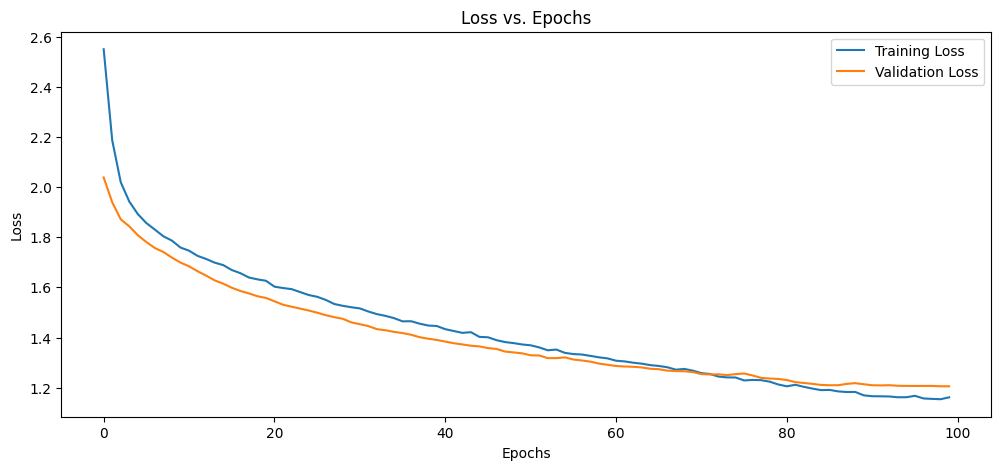

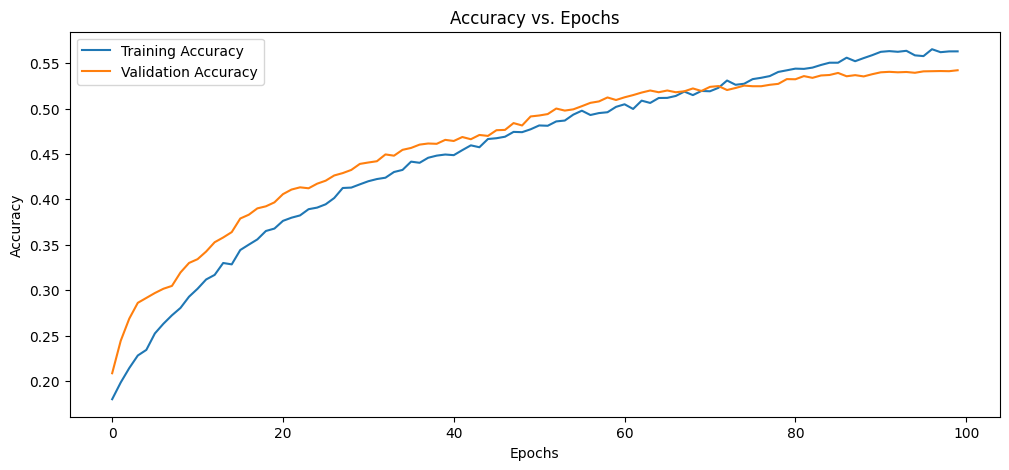

180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


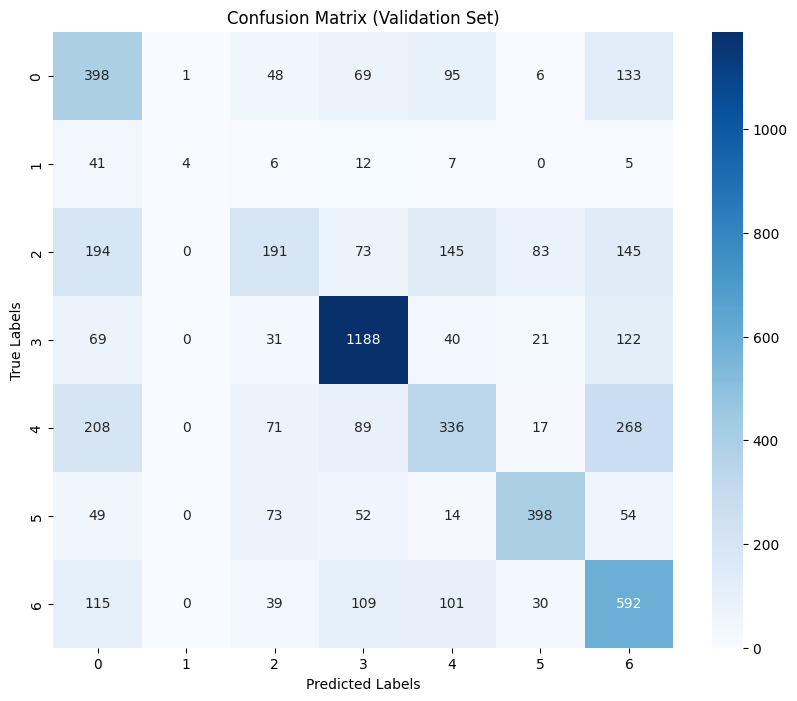

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.37      0.53      0.44       750
           1       0.80      0.05      0.10        75
           2       0.42      0.23      0.30       831
           3       0.75      0.81      0.78      1471
           4       0.46      0.34      0.39       989
           5       0.72      0.62      0.67       640
           6       0.45      0.60      0.51       986

    accuracy                           0.54      5742
   macro avg       0.56      0.45      0.45      5742
weighted avg       0.55      0.54      0.53      5742



In [ ]:
# Plot Training and Validation Loss and Accuracy
history = emotion_model.history.history

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# After training the model, extract the history object
history = emotion_model.history.history

# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Generate Predictions on the Validation Set
y_val_pred = np.argmax(emotion_model.predict(X_val_rgb), axis=1)
y_val_true = np.argmax(y_val, axis=1)

# Calculate and Plot Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(7), yticklabels=range(7))
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report for the Validation Set
print('Classification Report (Validation Set):')
print(classification_report(y_val_true, y_val_pred))
